# Connectivity Matrix Exploration

Explore structural and functional connectivity matrices, their value ranges, and direct and indirect connectivity patterns.

Run this notebook from the project root. See the [project overview](README.md) for the full analysis workflow.


In [1]:
import pandas as pd


base_path = "data/connectomes/"


In [2]:
def load_data(file_path):
    try:
        with open(file_path) as handle:
            header = next(line for line in handle if line.startswith("# name:"))
        labels = [label.strip() for label in header.split(":", 1)[1].split(",")]
        data = pd.read_csv(file_path, comment="#", header=None)
        data.index = labels
        data.columns = labels
        return data
    except Exception as e:
        print(f"Error loading data: {e}")
        return None

def load_pair(patient_id):
    wfa_file = f"{base_path}{patient_id}_WFA_68.csv"
    rsfmri_file = f"{base_path}{patient_id}_rsfMRI_68.csv"
    wfa_data = load_data(wfa_file)
    rsfmri_data = load_data(rsfmri_file)
    if wfa_data is not None and rsfmri_data is not None:
        return wfa_data, rsfmri_data
    else:
        print(f"Error loading data for patient {patient_id}")
        return None, None
    
example_patient_id = "32"
wfa_data, rsfmri_data = load_pair(example_patient_id)
if wfa_data is not None and rsfmri_data is not None:
    print("WFA Data:")
    print(wfa_data.head())
    print("\nrsfMRI Data:")
    print(rsfmri_data.head())

WFA Data:
                                       banks_superior_temporal_sulcus_left  \
banks_superior_temporal_sulcus_left                                    0.0   
caudal_anterior_cingulate_cortex_left                                  0.0   
caudal_middle_frontal_gyrus_left                                       0.0   
cuneus_left                                                            0.0   
entorhinal_cortex_left                                                 0.0   

                                       caudal_anterior_cingulate_cortex_left  \
banks_superior_temporal_sulcus_left                                 0.000000   
caudal_anterior_cingulate_cortex_left                               0.000000   
caudal_middle_frontal_gyrus_left                                    0.410457   
cuneus_left                                                         0.000000   
entorhinal_cortex_left                                              0.000000   

                                       c

In [3]:
"""
WFA Data:
                                               0         1         2    3    4
# name: banks_superior_temporal_sulcus_left  0.0  0.000000  0.000000  0.0  0.0
caudal_anterior_cingulate_cortex_left        0.0  0.000000  0.410457  0.0  0.0
caudal_middle_frontal_gyrus_left             0.0  0.410457  0.000000  0.0  0.0
cuneus_left                                  0.0  0.000000  0.000000  0.0  0.0
entorhinal_cortex_left                       0.0  0.000000  0.000000  0.0  0.0
...                                          ...       ...       ...  ...  ...
supramarginal_gyrus_right                    0.0  0.468821  0.452042  0.0  0.0
frontal_pole_right                           0.0  0.000000  0.000000  0.0  0.0
temporal_pole_right                          0.0  0.000000  0.000000  0.0  0.0
transverse_temporal_gyrus_right              0.0  0.000000  0.000000  0.0  0.0
insula_right                                 0.0  0.444004  0.420722  0.0  0.0


rsfMRI Data:
                                                    0         1         2  \
# name: banks_superior_temporal_sulcus_left  1.000000 -0.047939 -0.053131   
caudal_anterior_cingulate_cortex_left       -0.047939  1.000000 -0.011317   
caudal_middle_frontal_gyrus_left            -0.053131 -0.011317  1.000000   
cuneus_left                                  0.071442  0.070346  0.057832   
entorhinal_cortex_left                      -0.016532  0.056375 -0.003448   
...                                               ...       ...       ...   
supramarginal_gyrus_right                   -0.064049 -0.102719  0.086681   
transverse_temporal_gyrus_right             -0.003209  0.071053  
insula_right                                 0.120231  0.098605  

WFA Data: Structural conectivity, 
    0-1 ranges 0 indicates no connection, 
    1 indicates strong connection. 

rsfMRI Data: Functional connectivity, 
    -1 to 1 ranges, 
    -1 indicates strong negative correlation, 
    0 indicates no correlation, 
    1 indicates strong positive correlation.
"""


# check if the same regions are in both datasets
wfa_regions = set(wfa_data.index)
rsfmri_regions = set(rsfmri_data.index)
common_regions = wfa_regions.intersection(rsfmri_regions)
print(f"Number of regions in WFA data: {len(wfa_regions)}")
print(f"Number of regions in rsfMRI data: {len(rsfmri_regions)}")
print(f"Number of common regions: {len(common_regions)}")

Number of regions in WFA data: 68
Number of regions in rsfMRI data: 68
Number of common regions: 68


In [4]:
# range of values in WFA data and rsfMRI data (excluding 1s on the diagonal)
wfa_min, wfa_max = wfa_data.min().min(), wfa_data.max().max()
rsfmri_min, rsfmri_max = rsfmri_data.min().min(), rsfmri_data[rsfmri_data != 1].max().max()
print(f"WFA data range: {wfa_min} to {wfa_max}")
print(f"rsfMRI data range: {rsfmri_min} to {rsfmri_max}")

WFA data range: 0.0 to 0.536492480122137
rsfMRI data range: -0.462204107578187 to 0.196275248364571


In [5]:
# plot the connectivity matrices for the example patient, color indicating strength of connectivity/correlation, overlaying the two matrices to visually compare them
import matplotlib.pyplot as plt
def plot_connectivity_matrices(wfa_matrix, rsfmri_matrix, patient_id, greyscale=False):
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    
    im1 = axes[0].imshow(wfa_matrix, vmin=wfa_min, vmax=wfa_max, cmap='bwr' if not greyscale else 'gray')
    axes[0].set_title(f'WFA Connectivity - Patient {patient_id}')
    plt.colorbar(im1, ax=axes[0], fraction=0.046, pad=0.04)
    
    im2 = axes[1].imshow(rsfmri_matrix, vmin=rsfmri_min, vmax=rsfmri_max, cmap='bwr' if not greyscale else 'gray')
    axes[1].set_title(f'rsfMRI Connectivity - Patient {patient_id}')
    plt.colorbar(im2, ax=axes[1], fraction=0.046, pad=0.04)
    
    plt.tight_layout()
    plt.show()


In [6]:
import numpy as np

def indirect_connectivity(S):
    n = S.shape[0]
    T = np.zeros_like(S)
    for i in range(n):
        for j in range(n):
            if i == j:
                continue
            vals = []
            for k in range(n):
                if S[i,k] > 0 and S[k,j] > 0:
                    vals.append(min(S[i,k], S[k,j]))
            if vals:
                T[i,j] = max(vals)
    return T

In [7]:
wfa_matrix = indirect_connectivity(wfa_data.values)
rsfmri_matrix = rsfmri_data.values
print(wfa_matrix)
print(rsfmri_matrix)

[[0.         0.42255735 0.40971658 ... 0.         0.         0.42255735]
 [0.42255735 0.         0.49604311 ... 0.32162235 0.46948489 0.45943316]
 [0.40971658 0.49604311 0.         ... 0.34516057 0.46948489 0.43447875]
 ...
 [0.         0.32162235 0.34516057 ... 0.         0.34516057 0.34516057]
 [0.         0.46948489 0.46948489 ... 0.34516057 0.         0.42188022]
 [0.42255735 0.45943316 0.43447875 ... 0.34516057 0.42188022 0.        ]]
[[ 1.         -0.04793857 -0.05313105 ... -0.03044161  0.02446049
  -0.03625003]
 [-0.04793857  1.         -0.01131744 ... -0.03899013  0.12778881
  -0.13470584]
 [-0.05313105 -0.01131744  1.         ...  0.04083906 -0.01570139
   0.0220822 ]
 ...
 [-0.03044161 -0.03899013  0.04083906 ...  1.          0.04072357
  -0.13218139]
 [ 0.02446049  0.12778881 -0.01570139 ...  0.04072357  1.
  -0.02298094]
 [-0.03625003 -0.13470584  0.0220822  ... -0.13218139 -0.02298094
   1.        ]]


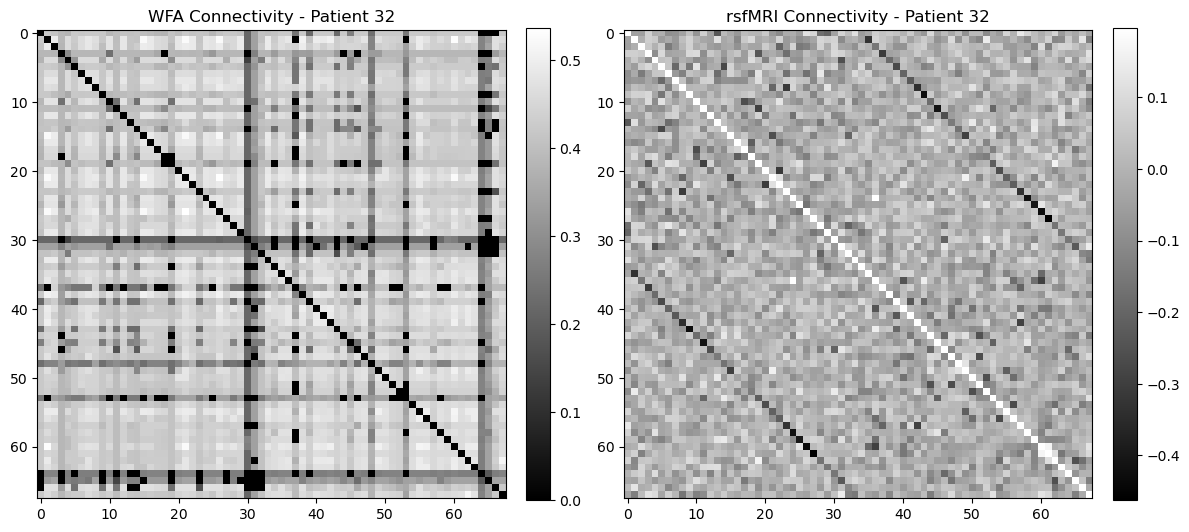

In [8]:
plot_connectivity_matrices(wfa_matrix, rsfmri_matrix, example_patient_id, greyscale=True)

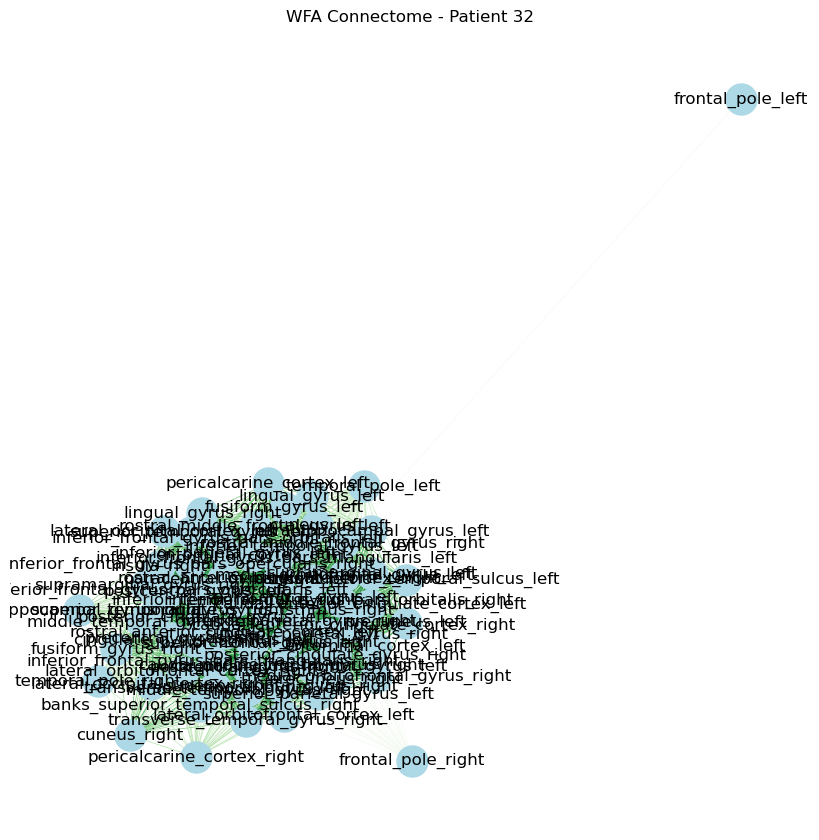

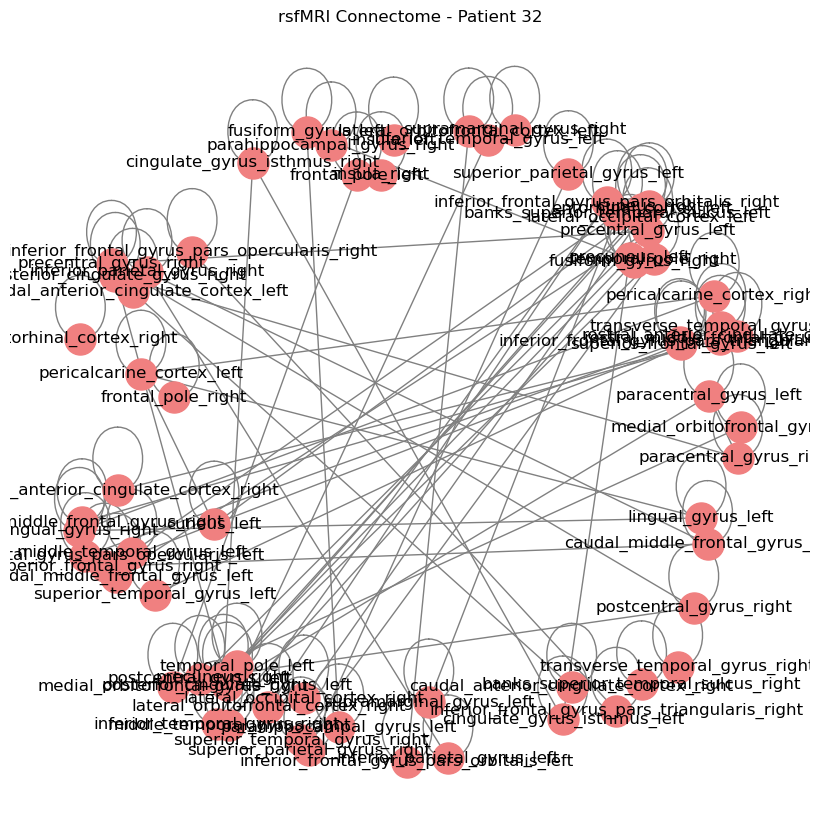

In [9]:
import networkx

def filter_matrix(matrix, threshold):
    filtered = np.copy(matrix)
    filtered[abs(filtered) < threshold] = 0
    return filtered

def plot_wfa_connectome(matrix, names, title=''): # color indicating strength of connectivity
    G = networkx.from_numpy_array(matrix)
    for  u,v,d in G.edges(data=True):
        d['weight'] = matrix[u,v]
    edges, weights = zip(*networkx.get_edge_attributes(G, 'weight').items())
    pos = networkx.spring_layout(G)
    plt.figure(figsize=(8, 8))
    networkx.draw(G, pos, with_labels=True, labels={i: names[i] for i in range(len(names))}, node_size=500, node_color='lightblue', edgelist=edges, edge_color=weights, width=0.5, edge_cmap=plt.cm.Greens)
    plt.title(title)
    plt.show()


def plot_rsfmri_connectome(matrix, names, title=''):
    G = networkx.from_numpy_array(matrix)
    pos = networkx.spring_layout(G)
    plt.figure(figsize=(8, 8))
    networkx.draw(G, pos, with_labels=True, labels={i: names[i] for i in range(len(names))}, node_size=500, node_color='lightcoral', edge_color='gray')
    plt.title(title)
    plt.show()

plot_wfa_connectome(filter_matrix(wfa_matrix, 0.27), wfa_data.index, title=f'WFA Connectome - Patient {example_patient_id}')
plot_rsfmri_connectome(filter_matrix(rsfmri_matrix, 0.2), rsfmri_data.index, title=f'rsfMRI Connectome - Patient {example_patient_id}')

In [10]:
strongest_rsfmri_matrix = filter_matrix(rsfmri_matrix, 0.1)
overlapping_wfa_matrix = np.where(strongest_rsfmri_matrix != 0, wfa_matrix, 0)
node_labels = wfa_data.index.tolist()
strongest_rsfmri_matrix = pd.DataFrame(strongest_rsfmri_matrix, index=wfa_data.index, columns=wfa_data.index)
overlapping_wfa_matrix = pd.DataFrame(overlapping_wfa_matrix, index=wfa_data.index, columns=wfa_data.index)

print(strongest_rsfmri_matrix)
print(overlapping_wfa_matrix)

# str_rsfmri = nx.convert_matrix.from_pandas_adjacency(strongest_rsfmri_matrix)

                                       banks_superior_temporal_sulcus_left  \
banks_superior_temporal_sulcus_left                                    1.0   
caudal_anterior_cingulate_cortex_left                                  0.0   
caudal_middle_frontal_gyrus_left                                       0.0   
cuneus_left                                                            0.0   
entorhinal_cortex_left                                                 0.0   
...                                                                    ...   
supramarginal_gyrus_right                                              0.0   
frontal_pole_right                                                     0.0   
temporal_pole_right                                                    0.0   
transverse_temporal_gyrus_right                                        0.0   
insula_right                                                           0.0   

                                       caudal_anterior_cingulat